In [1]:
import cv2
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import os
from nms import postprocess_predictions
from data_utils import load_preds_csv, df_to_pred_dict, df_to_gt_dict


### Predictions

In [ ]:

# Load your predictions
csv_path_pred = '/home/deniz/waggle_dance_detector/inference_results/multi_threshold_results_epoch_195/preds0.8.csv'
pred_df = load_preds_csv(csv_path_pred)
print(pred_df.head())
print(f"Number of Predictions: {len(pred_df)}")
print(f"Shape of Predictions: {pred_df.shape}")


CSV Info:
Shape: (430, 8)
Columns: ['Unnamed: 0', 'start', 'end', 'x', 'y', 'dir_x', 'dir_y', 'confidence']

First 10 rows:
   Unnamed: 0  start  end           x           y     dir_x     dir_y  \
0           0     28   43  190.424011  453.367096  0.218160  0.975913   
1           1     33   47  194.117691  453.114502  0.227171  0.973855   
2           2    101  107  178.884186  444.164520  0.338792 -0.940861   
3           3    103  111  174.544662  444.566406  0.349069 -0.937097   
4           4    104  115  179.771393  445.137329  0.331087 -0.943600   
5           5    213  227  173.911728  441.310089 -0.176636 -0.984276   
6           6    217  231  173.433304  442.866211 -0.172645 -0.984984   
7           7    221  235  181.272903  444.700928 -0.184630 -0.982808   
8           8    224  239  179.395325  444.084747 -0.202170 -0.979350   
9           9    296  309  153.415573  487.421204  0.177265  0.984163   

   confidence  
0    0.868559  
1    0.866998  
2    0.802478  
3    0.8

In [8]:
csv_path_gt = '/home/deniz/waggle_dance_detector/dataset/eval_gt/Capture_2025-04-29_14-59-11-1-00.00.01.000-00.02.00.688_downsampled_95.csv'
data = pd.read_csv(csv_path_gt)
data = data.drop(columns=['video_name'])
print(data.head())
print(f"Number of GT: {len(data)}")

   Unnamed: 0  start_frame  end_frame          x1          y1     x2     y2  \
0           0           94        110  177.000000  449.000000  186.0  437.0   
1           1           98        114  177.000000  449.000000  186.0  437.0   
2           2          102        118  177.000000  449.000000  186.0  437.0   
3           3          105        121  177.000000  449.000000  186.0  437.0   
4           4          109        125  178.636364  446.818182  186.0  437.0   

     angle  waggle  origin_x  origin_y  direction_x  direction_y  \
0 -1.04688       1     177.0     449.0     0.500278     -0.86587   
1 -1.04688       1     177.0     449.0     0.500278     -0.86587   
2 -1.04688       1     177.0     449.0     0.500278     -0.86587   
3 -1.04688       1     177.0     449.0     0.500278     -0.86587   
4 -1.04688       1     177.0     449.0     0.500278     -0.86587   

   waggle_run_id  waggle_start  waggle_end  waggle_start_in_window  \
0              1           105         127    

### Post Processing

In [9]:
# Load and process your data
csv_path_pred = '/home/deniz/waggle_dance_detector/inference_results/multi_threshold_results_epoch_195/preds0.8.csv'
pred_df = pd.read_csv(csv_path_pred)

csv_path_gt = '/home/deniz/waggle_dance_detector/dataset/eval_gt/Capture_2025-04-29_14-59-11-1-00.00.01.000-00.02.00.688_downsampled_95.csv'
gt_df = pd.read_csv(csv_path_gt)
gt_df = gt_df.drop(columns=['video_name'])

print(f"Number of Predictions: {len(pred_df)}")
print(f"Number of GT: {len(gt_df)}")

# Convert to dictionary format
predictions = df_to_pred_dict(pred_df)
gt_data = df_to_gt_dict(gt_df)

print(f"Converted {len(predictions)} predictions to dictionary format")
print(f"Converted {len(gt_data)} ground truth entries to dictionary format")

Number of Predictions: 430
Number of GT: 1731
Converted 430 predictions to dictionary format
Converted 1731 ground truth entries to dictionary format


In [10]:
# Post-process predictions
results = postprocess_predictions(predictions)
final_predictions = results['filtered_predictions']
waggle_trajectories = results['trajectories']

print(f"\n=== POST-PROCESSING RESULTS ===")
print(f"Original predictions: {len(predictions)}")
print(f"After filtering: {len(final_predictions)}")
print(f"Number of waggle trajectories: {len(waggle_trajectories)}")


=== POST-PROCESSING RESULTS ===
Original predictions: 430
After filtering: 184
Number of waggle trajectories: 22


In [11]:
# Convert filtered predictions back to DataFrame 
filtered_df = pd.DataFrame(final_predictions)
print(f"\nFiltered predictions head:")
print(filtered_df.head())

# Conert to csv
filtered_df.to_csv('/home/deniz/waggle_dance_detector/inference_results/filtered_preds.csv', index=False)


Filtered predictions head:
   start   end           x           y     dir_x     dir_y  confidence
0   2376  2391  223.391083  454.763428  0.220399  0.975410    0.992926
1   2024  2039  212.203491  447.263733  0.120243  0.992745    0.990959
2    676   691  155.361465  487.935486  0.140073  0.990141    0.990696
3   1100  1115  150.270554  477.756256  0.086049  0.996291    0.990663
4   1384  1399  190.677017  455.882263  0.247045  0.969004    0.990410


### Visualize results

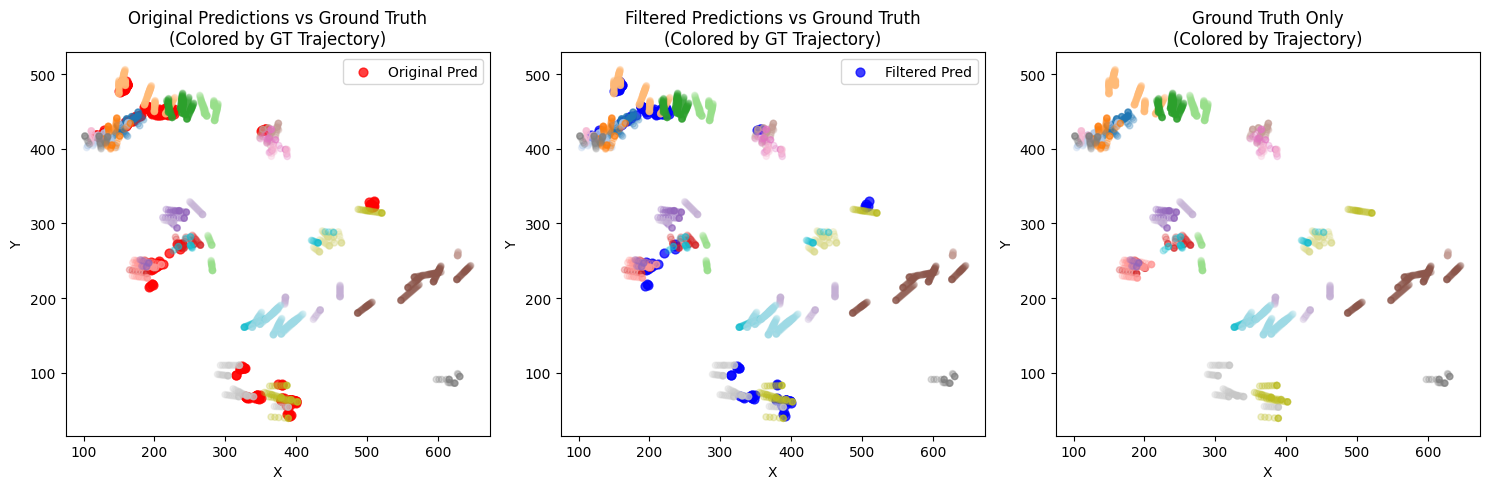

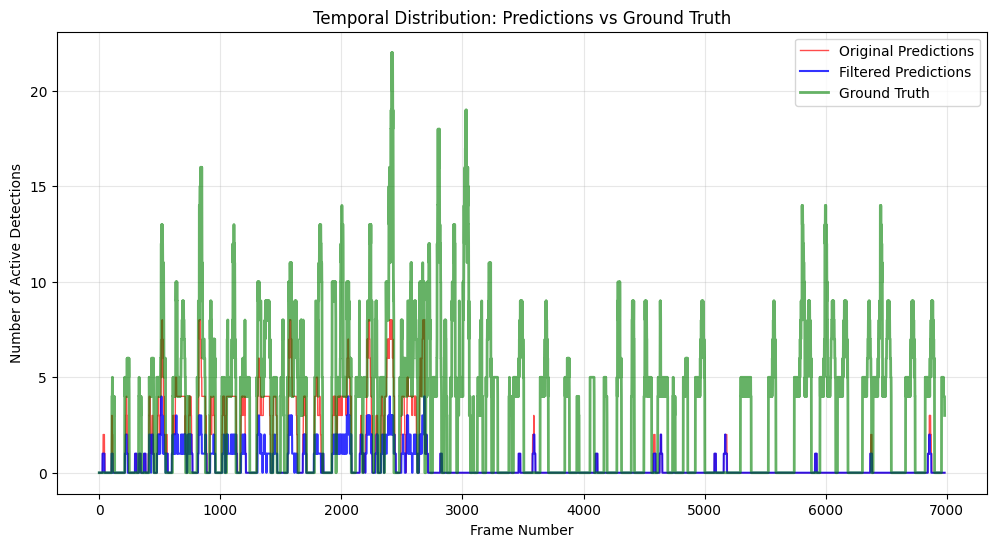

In [12]:
# 1. Spatial distribution comparison with colored GT trajectories
plt.figure(figsize=(15, 5))

# Get unique waggle_run_ids and assign colors
unique_gt_ids = list(set(g['waggle_run_id'] for g in gt_data))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_gt_ids)))
color_map = {gt_id: colors[i] for i, gt_id in enumerate(unique_gt_ids)}

plt.subplot(1, 3, 1)
# Original predictions
plt.scatter([p['x'] for p in predictions], [p['y'] for p in predictions], 
           c='red', alpha=0.75, label='Original Pred', s=40)

# Ground truth with trajectory colors
for gt_id, color in color_map.items():
    traj_points = [g for g in gt_data if g['waggle_run_id'] == gt_id]
    if traj_points:
        plt.scatter([g['x'] for g in traj_points], [g['y'] for g in traj_points], 
                   c=[color] * len(traj_points), alpha=0.25, s=20, marker='o')

plt.title('Original Predictions vs Ground Truth\n(Colored by GT Trajectory)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.subplot(1, 3, 2)
# Filtered predictions
plt.scatter([p['x'] for p in final_predictions], [p['y'] for p in final_predictions], 
           c='blue', alpha=0.75, label='Filtered Pred', s=40)

# Ground truth with trajectory colors
for gt_id, color in color_map.items():
    traj_points = [g for g in gt_data if g['waggle_run_id'] == gt_id]
    if traj_points:
        plt.scatter([g['x'] for g in traj_points], [g['y'] for g in traj_points], 
                   c=[color] * len(traj_points), alpha=0.25, s=20, marker='o')

plt.title('Filtered Predictions vs Ground Truth\n(Colored by GT Trajectory)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.subplot(1, 3, 3)
# Show only ground truth with trajectory colors
for gt_id, color in color_map.items():
    traj_points = [g for g in gt_data if g['waggle_run_id'] == gt_id]
    if traj_points:
        plt.scatter([g['x'] for g in traj_points], [g['y'] for g in traj_points], 
                   c=[color] * len(traj_points), alpha=0.25, s=20, marker='o')

plt.title('Ground Truth Only\n(Colored by Trajectory)')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

# 2. Temporal distribution with ground truth
plt.figure(figsize=(12, 6))

max_frame = max(
    max(p['end'] for p in predictions) if predictions else 0,
    max(g['end'] for g in gt_data) if gt_data else 0
)

frame_numbers = list(range(max_frame + 1))

# Count active predictions/GT per frame
original_counts = [sum(1 for p in predictions if p['start'] <= frame <= p['end']) for frame in frame_numbers]
filtered_counts = [sum(1 for p in final_predictions if p['start'] <= frame <= p['end']) for frame in frame_numbers]
gt_counts = [sum(1 for g in gt_data if g['start'] <= frame <= g['end']) for frame in frame_numbers]

plt.plot(frame_numbers, original_counts, 'r-', alpha=0.7, label='Original Predictions', linewidth=1)
plt.plot(frame_numbers, filtered_counts, 'b-', alpha=0.8, label='Filtered Predictions', linewidth=1.5)
plt.plot(frame_numbers, gt_counts, 'g-', alpha=0.6, label='Ground Truth', linewidth=2)

plt.xlabel('Frame Number')
plt.ylabel('Number of Active Detections')
plt.legend()
plt.title('Temporal Distribution: Predictions vs Ground Truth')
plt.grid(True, alpha=0.3)
plt.show()
